# One common explanation of neural networks is that multiple layers/wide networks + non-linearities help linear combinations learn non-linear functions

I will visualize this in multiple contexts

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.optim as optim

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Let's start with a simple sine wave

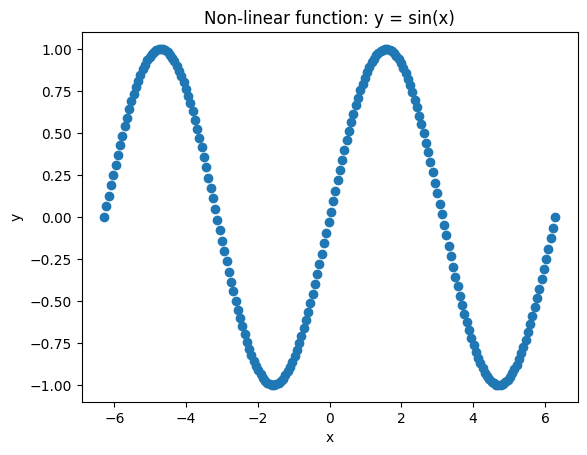

In [3]:
# Generate data
x = np.linspace(-2*np.pi, 2*np.pi, 200)
y = np.sin(x)

# Plot
plt.figure()
plt.scatter(x, y)
plt.title("Non-linear function: y = sin(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Let's design a moderately wide and deep neural network with ReLU activation to learn this in linspace

In [75]:
class SinModel(nn.Module):
  def __init__(self, hidden_dim, depth=1, act=None):
    super().__init__()
    self.hidden_dim = hidden_dim
    self.depth = depth

    self.fc1 = nn.Linear(1, hidden_dim)

    layers = []
    for _ in range(depth):
      layers.append(nn.Linear(hidden_dim, hidden_dim))
      if act is not None:
        layers.append(act)

    self.hidden_layers = nn.Sequential(*layers)

    self.fc2 = nn.Linear(hidden_dim, 1)

    self.act = act

  def forward(self, x):
    x = self.fc1(x)
    if self.act is not None:
      x = self.act(x)
    x = self.hidden_layers(x)
    x = self.fc2(x)
    return x

## Our input will be 10000 evenly-distributed points from -10 to 10

In [76]:
xs = torch.tensor(np.linspace(-10, 10, 10000))
xs = xs.float().view(-1, 1) # reshape to be batched

In [77]:
def plot_curves(pred_xs, pred_ys):
  # Plot
  plt.figure()
  plt.scatter(xs, ys)
  plt.scatter(pred_xs, pred_ys, color='red')
  plt.title("Non-linear function: y = sin(x)")
  plt.xlabel("x")
  plt.ylabel("y")
  plt.show()

## Our `ys` apply Sin to each of these points

In [78]:
ys = torch.tensor(np.sin(xs))
ys = ys.float().view(-1, 1) # reshape to be batched

/var/folders/dv/3rt9dzq92qq4mwb8qz5mh_cw0000gn/T/ipykernel_6827/1744824731.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ys = torch.tensor(np.sin(xs))
/var/folders/dv/3rt9dzq92qq4mwb8qz5mh_cw0000gn/T/ipykernel_6827/1744824731.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ys = torch.tensor(np.sin(xs))


In [79]:
full_dataset = torch.utils.data.TensorDataset(xs, ys)
dataset_size = len(full_dataset)
train_size = int(0.8 * dataset_size)
test_size = int(0.2 * dataset_size)

train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# can make num_workers > 0 to prevent CPU from becoming bottleneck in loading data (parallel cores)
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=True, num_workers=0)

In [80]:
test_xs = test_dataset.dataset.tensors[0][test_dataset.indices]
test_ys = test_dataset.dataset.tensors[1][test_dataset.indices]

test_xs_np = test_xs.cpu().numpy()
test_ys_np = test_ys.cpu().numpy()

In [81]:
def train(model, optimizer, criterion, dataloader, epochs=10):
  loss_list = []
  model.train()
  for epoch in range(epochs):
    cur_loss = []
    for features, targets in dataloader:
      features = features.float().to(device)
      targets = targets.float().to(device)
      optimizer.zero_grad()
      preds = model(features)
      loss = criterion(preds, targets)
      cur_loss.append(loss.item())
      loss_list.append(loss.item())
      loss.backward()
      optimizer.step()
    print(f"Epoch {epoch} average loss: {np.mean(cur_loss)}")

  return loss_list

Epoch 0 average loss: 0.28334428694844244
Epoch 1 average loss: 0.19601541932672262
Epoch 2 average loss: 0.15566055991500616
Epoch 3 average loss: 0.13800563890114426
Epoch 4 average loss: 0.12274449557811022
Epoch 5 average loss: 0.11024935399368406
Epoch 6 average loss: 0.09650730033498257
Epoch 7 average loss: 0.06831107623432763
Epoch 8 average loss: 0.024532993241911754
Epoch 9 average loss: 0.00585437613382237


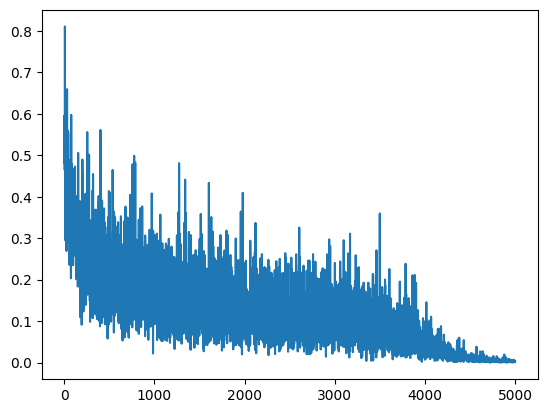

In [82]:
sin_nn = SinModel(128, act=nn.Tanh())
optimizer = optim.Adam(sin_nn.parameters(), lr=1e-3)
mse_loss = nn.MSELoss() 

sin_nn.to(device)
loss_list = train(sin_nn, optimizer, mse_loss, train_dataloader)
plt.plot(loss_list)

In [83]:
test_preds = sin_nn(test_xs)
test_preds_np = test_preds.detach().numpy()

## Tanh with a single hidden layer, 128-wide network works well!

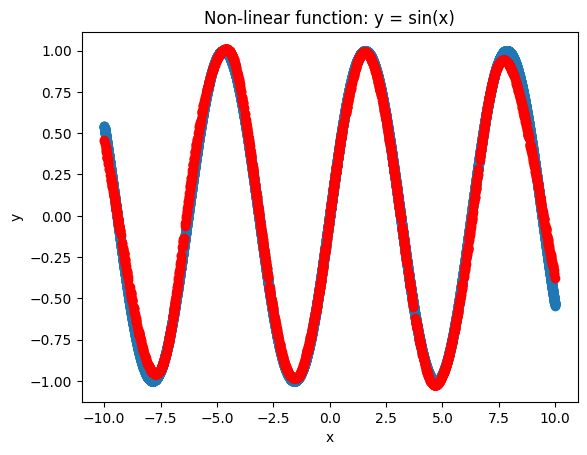

In [84]:
plot_curves(test_xs_np, test_preds_np)

## ReLU struggles at smaller widths but works better for very wide networks

Epoch 0 average loss: 0.4429918866753578
Epoch 1 average loss: 0.3467112685739994
Epoch 2 average loss: 0.2892277492284775
Epoch 3 average loss: 0.22937190525978804
Epoch 4 average loss: 0.18195183166861534
Epoch 5 average loss: 0.1638226710408926
Epoch 6 average loss: 0.15491122417058795
Epoch 7 average loss: 0.1460947343390435
Epoch 8 average loss: 0.13975276822224258
Epoch 9 average loss: 0.13560010052658616


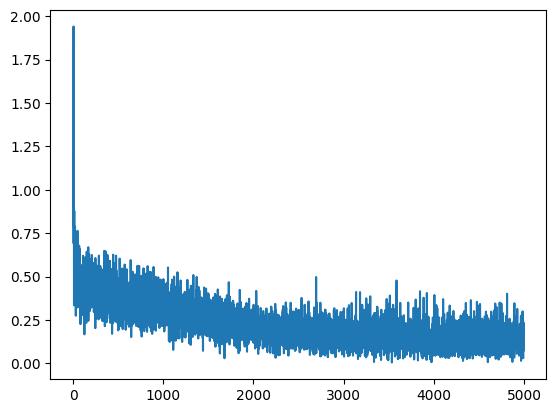

In [86]:
sin_nn_relu = SinModel(16, act=nn.ReLU()) 
sin_nn_relu.to(device)
optimizer = optim.Adam(sin_nn_relu.parameters(), lr=1e-3)
loss_list = train(sin_nn_relu, optimizer, mse_loss, train_dataloader)
plt.plot(loss_list)

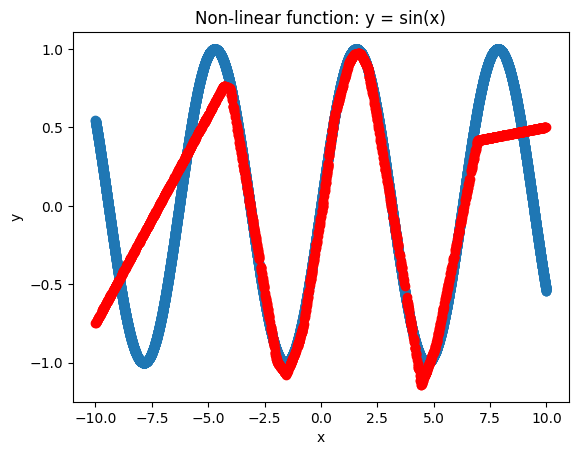

In [87]:
test_preds_relu = sin_nn_relu(test_xs)
test_preds_relu_np = test_preds_relu.detach().numpy()
plot_curves(test_xs_np, test_preds_relu_np)

Epoch 0 average loss: 0.2864935278557241
Epoch 1 average loss: 0.17413305905088783
Epoch 2 average loss: 0.13328799243830144
Epoch 3 average loss: 0.09393543138820679
Epoch 4 average loss: 0.06752066782535986
Epoch 5 average loss: 0.047984330331208185
Epoch 6 average loss: 0.03414392098947428
Epoch 7 average loss: 0.013904633653932252
Epoch 8 average loss: 0.007553085799620021
Epoch 9 average loss: 0.0046401882012723945


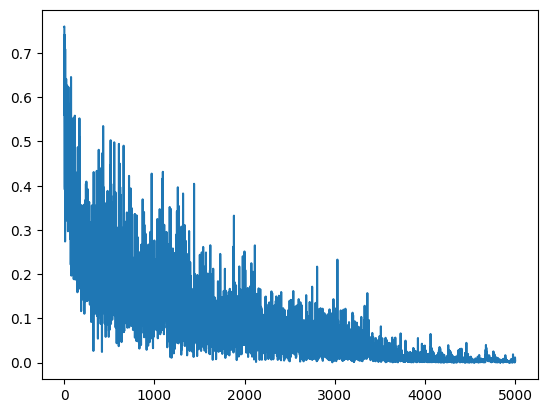

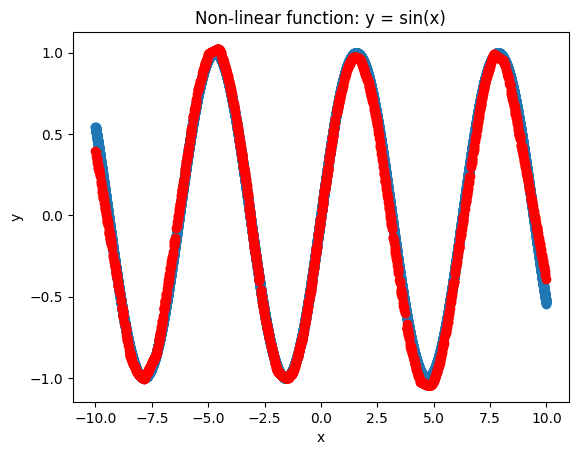

In [89]:
sin_nn = SinModel(128, act=nn.ReLU()) 
sin_nn.to(device)
optimizer = optim.Adam(sin_nn.parameters(), lr=1e-3)
loss_list = train(sin_nn, optimizer, mse_loss, train_dataloader, 10)
plt.plot(loss_list)

test_preds_relu_large = sin_nn(test_xs)
test_preds_relu_large_np = test_preds_relu_large.detach().numpy()
plot_curves(test_xs_np, test_preds_relu_large_np)

## Tanh works ok with a small network"

Epoch 0 average loss: 0.372674375385046
Epoch 1 average loss: 0.21271687123179436
Epoch 2 average loss: 0.1804540733397007
Epoch 3 average loss: 0.16459097564965486
Epoch 4 average loss: 0.15774420653283597
Epoch 5 average loss: 0.14717550043016672
Epoch 6 average loss: 0.14425142391771079
Epoch 7 average loss: 0.13744876914843918
Epoch 8 average loss: 0.1344437626004219
Epoch 9 average loss: 0.1311931687258184


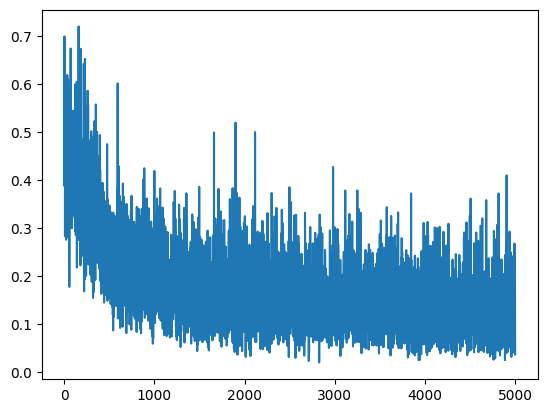

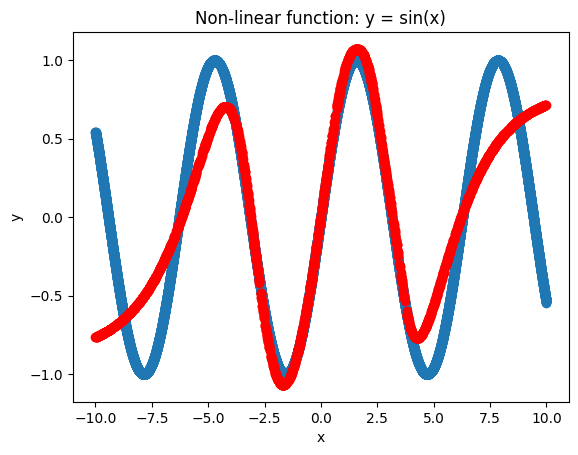

In [90]:
sin_nn_tanh_small = SinModel(32, act=nn.Tanh()) 
sin_nn_tanh_small.to(device)
optimizer = optim.Adam(sin_nn_tanh_small.parameters(), lr=1e-3)
loss_list = train(sin_nn_tanh_small, optimizer, mse_loss, train_dataloader)
plt.plot(loss_list)

test_preds_tanh_small = sin_nn_tanh_small(test_xs)
test_preds_tanh_small_np = test_preds_tanh_small.detach().numpy()
plot_curves(test_xs_np, test_preds_tanh_small_np)

## Let's see what happens if we design a model without non-linearities

Epoch 0 average loss: 0.48024295380711557
Epoch 1 average loss: 0.4721833140850067
Epoch 2 average loss: 0.4676609822511673
Epoch 3 average loss: 0.467180251210928
Epoch 4 average loss: 0.46513900950551035
Epoch 5 average loss: 0.4638654509484768
Epoch 6 average loss: 0.462846697896719
Epoch 7 average loss: 0.4615470160841942
Epoch 8 average loss: 0.46151730448007583
Epoch 9 average loss: 0.4613108521103859


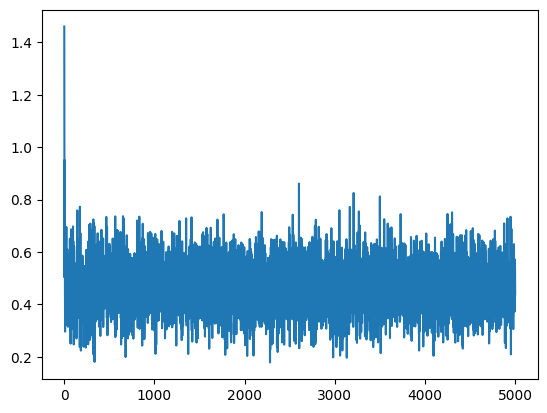

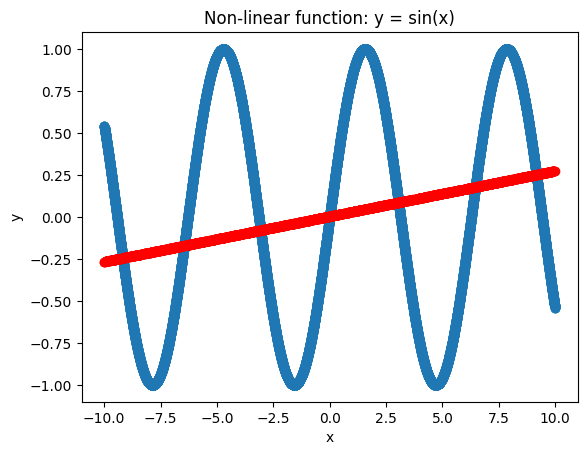

In [91]:
sin_nn_none = SinModel(32) 
sin_nn_none.to(device)
optimizer = optim.Adam(sin_nn_none.parameters(), lr=1e-3)
loss_list = train(sin_nn_none, optimizer, mse_loss, train_dataloader)
plt.plot(loss_list)

test_preds_none = sin_nn_none(test_xs).detach().numpy()
plot_curves(test_xs_np, test_preds_none)

Epoch 0 average loss: 0.9021775354146957
Epoch 1 average loss: 0.5230298258364201
Epoch 2 average loss: 0.5143916325569153
Epoch 3 average loss: 0.48421985080838204
Epoch 4 average loss: 0.46646629267930984
Epoch 5 average loss: 0.4655954746603966
Epoch 6 average loss: 0.46394756153225897
Epoch 7 average loss: 0.4630190312862396
Epoch 8 average loss: 0.4621680998802185
Epoch 9 average loss: 0.4664492783844471


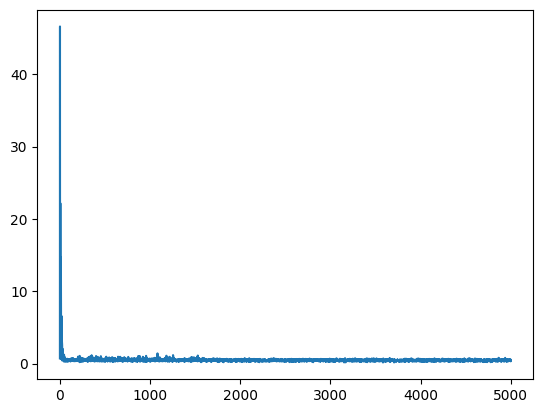

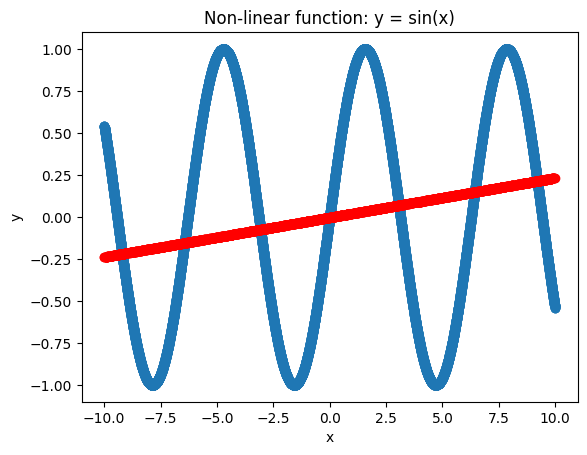

In [92]:
sin_nn_none = SinModel(256) 
sin_nn_none.to(device)
optimizer = optim.Adam(sin_nn_none.parameters(), lr=1e-3)
loss_list = train(sin_nn_none, optimizer, mse_loss, train_dataloader)
plt.plot(loss_list)

test_preds_none = sin_nn_none(test_xs).detach().numpy()
plot_curves(test_xs_np, test_preds_none)

> Conclusion: we cannot learn non-linear behaviors without a non-linear activation function. Some activations are more suited than others.

In [100]:
def generate_preds(width, activation, depth=1):
  sin_nn = SinModel(width, depth=depth, act=activation) 
  sin_nn.to(device)
  optimizer = optim.Adam(sin_nn.parameters(), lr=1e-3)
  loss_list = train(sin_nn, optimizer, mse_loss, train_dataloader)
  plt.plot(loss_list)

  test_preds = sin_nn(test_xs).detach().numpy()
  plot_curves(test_xs_np, test_preds)

Epoch 0 average loss: 0.46671272748708725
Epoch 1 average loss: 0.45511549577116966
Epoch 2 average loss: 0.43548999992012977
Epoch 3 average loss: 0.40123644718527796
Epoch 4 average loss: 0.35468334567546844
Epoch 5 average loss: 0.30472149151563643
Epoch 6 average loss: 0.26801917622983457
Epoch 7 average loss: 0.24276637470722198
Epoch 8 average loss: 0.22283310398459436
Epoch 9 average loss: 0.2092687096297741


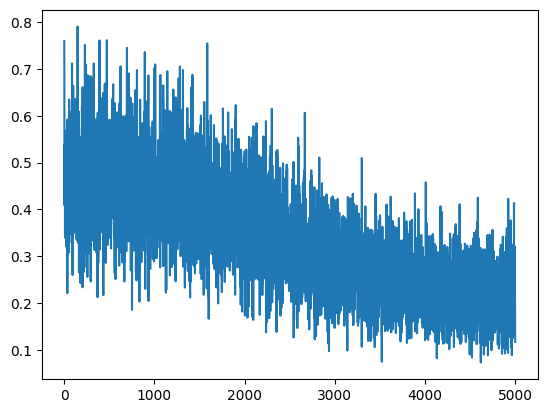

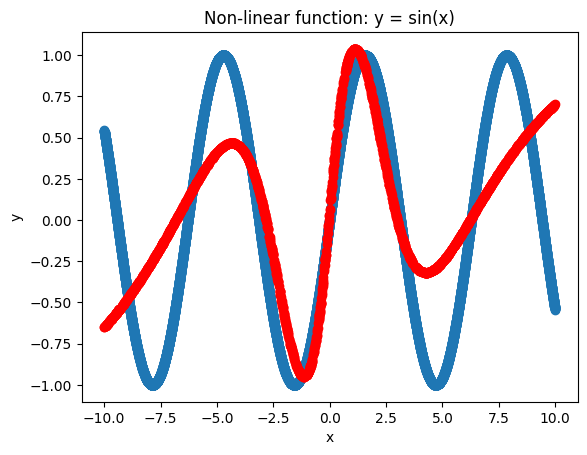

In [97]:
generate_preds(32, nn.Sigmoid())

Epoch 0 average loss: 0.4231880597770214
Epoch 1 average loss: 0.2813543521389365
Epoch 2 average loss: 0.1753267963603139
Epoch 3 average loss: 0.15085801385901867
Epoch 4 average loss: 0.1400499163940549
Epoch 5 average loss: 0.13497517531039194
Epoch 6 average loss: 0.12705468281172216
Epoch 7 average loss: 0.1232736484205816
Epoch 8 average loss: 0.1162353289363673
Epoch 9 average loss: 0.11134239504858852


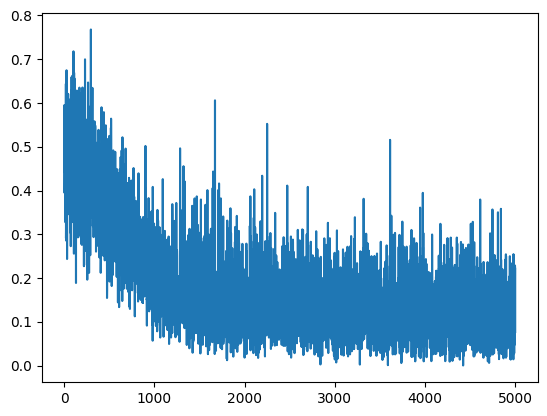

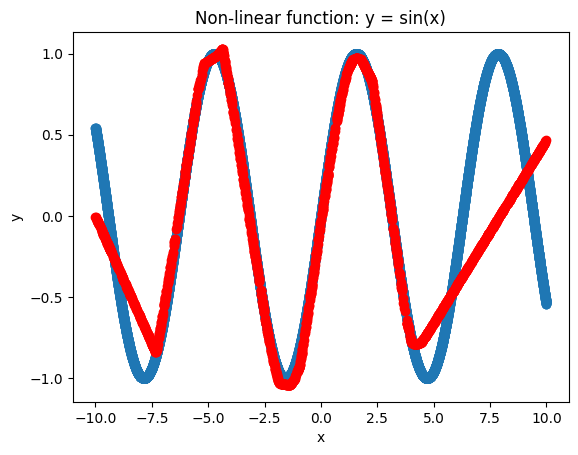

In [98]:
generate_preds(32, nn.PReLU())

/opt/homebrew/lib/python3.10/site-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Epoch 0 average loss: 0.47501168313622477
Epoch 1 average loss: 0.4649585140645504
Epoch 2 average loss: 0.45459817367792127
Epoch 3 average loss: 0.4503632891178131
Epoch 4 average loss: 0.44828516548871994
Epoch 5 average loss: 0.4451947307288647
Epoch 6 average loss: 0.43357386910915374
Epoch 7 average loss: 0.4022860420644283
Epoch 8 average loss: 0.3462850582003593
Epoch 9 average loss: 0.27496660126745703


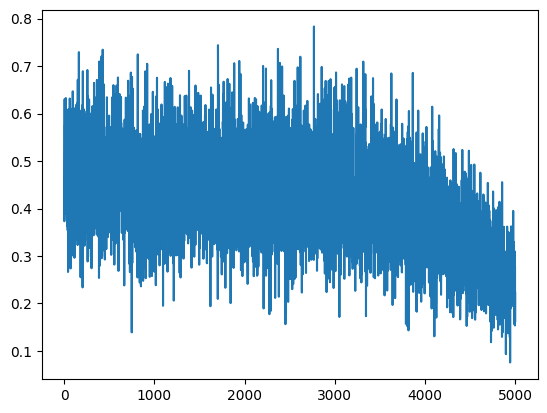

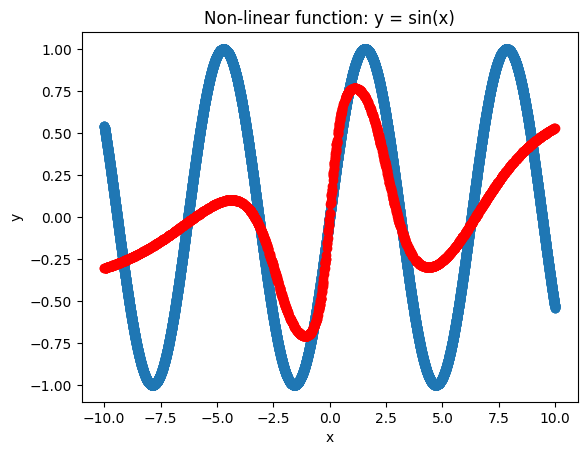

In [99]:
generate_preds(32, nn.Softmax())

## How does depth affect performance?

Epoch 0 average loss: 0.39438301622867583
Epoch 1 average loss: 0.2804362471550703
Epoch 2 average loss: 0.2524521576538682
Epoch 3 average loss: 0.24104856479167938
Epoch 4 average loss: 0.24575523240119218
Epoch 5 average loss: 0.23812819724529982
Epoch 6 average loss: 0.1910984224304557
Epoch 7 average loss: 0.15141217478364705
Epoch 8 average loss: 0.14039575420320033
Epoch 9 average loss: 0.13411859621107577


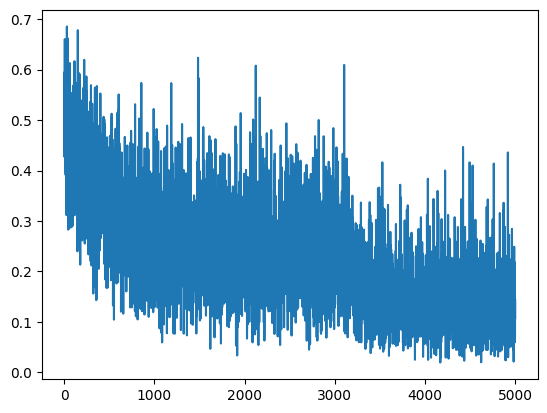

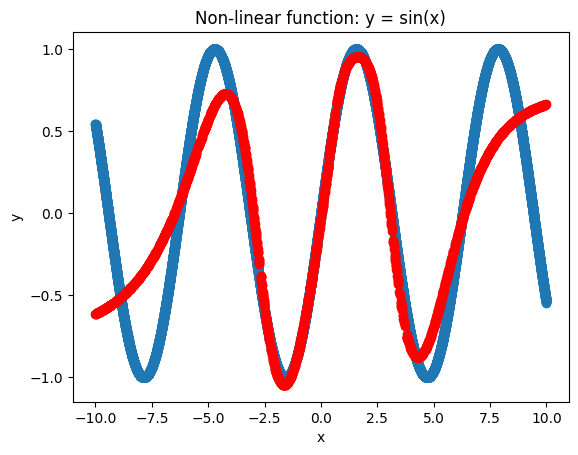

In [102]:
generate_preds(16, nn.Tanh(), depth=3)

Epoch 0 average loss: 0.41041035689413546
Epoch 1 average loss: 0.17835852748155595
Epoch 2 average loss: 0.11746935844048857
Epoch 3 average loss: 0.11505213720351458
Epoch 4 average loss: 0.10784467235952616
Epoch 5 average loss: 0.0944274557903409
Epoch 6 average loss: 0.03837046953290701
Epoch 7 average loss: 0.01619821092230268
Epoch 8 average loss: 0.004612610050651711
Epoch 9 average loss: 0.004370256392750889


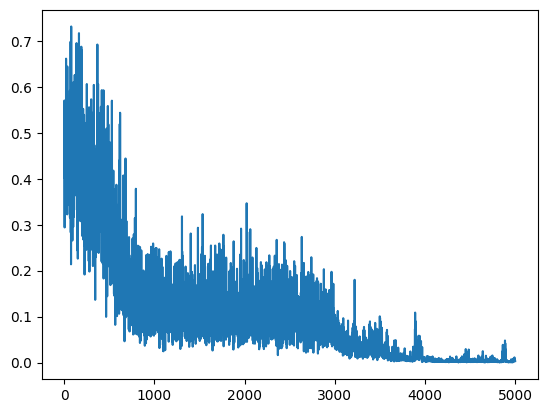

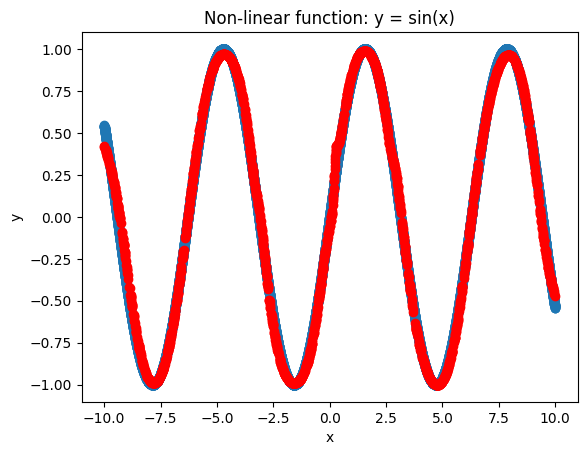

In [103]:
generate_preds(16, nn.Tanh(), depth=8)